In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from core.GraphCreator import GraphCreator
from core.PlotGraph import plotGraph

In [79]:
output = pd.read_csv("output.csv")
inputs = pd.read_csv("config/atomicInputs.csv")
inputs.set_index("node", inplace=True)
display(output)

,node,SCT
0,crystal_chronicles:bronchus_planks,1.25
1,suppsquared:item_shelf_jungle,0.63
2,born_in_chaos_v1:great_reaper_axe,15305.00
3,protection_pixel:hellsnakeas_chestplate,4885.84
4,sophisticatedstorage:diamond_to_netherite_tier...,78.40
...,...,...
3494,minecraft:hay_block,270.00
3495,create:raw_zinc_block,225.00
3496,#zinc_ores,25.00
3497,#dark_metal_ores,400.00


# Outliers

In [56]:
display(output[output["SCT"] > 1e7])

,node,SCT


In [16]:
with open('fullGraph.gpickle', 'rb') as f:
    gc : GraphCreator = pickle.load(f)

In [19]:
for node,data in gc.G.nodes.data():
    if data["type"] == "cycle":
        for subnode in data["subgraph"].nodes:
            if subnode == "irons_spellbooks:invisibility_elixir":
                print(node)

cycle-81


In [22]:
plotGraph(gc.G.nodes["cycle-81"]["subgraph"], "cycle-invisibility", fixedInOut=False)

cycle-invisibility.html


# Distribution

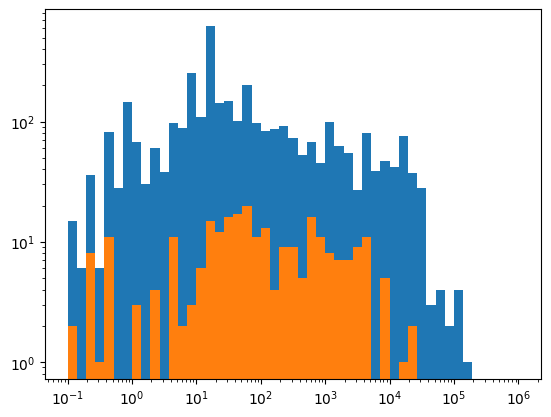

In [89]:
plt.figure()
plt.hist(output['SCT'],bins=np.geomspace(0.1, 1e6, 50))
plt.hist(inputs['value'],bins=np.geomspace(0.1, 1e6, 50))
plt.xscale('log')
plt.yscale('log')
plt.show()